In [1]:
from src.utils.dev_utils import is_running_in_databricks
import os

if not is_running_in_databricks():
    print("Running in local IDE - setting up Databricks Connect")
    from databricks.connect import DatabricksSession

    for env_var in [
        "DATABRICKS_AUTH_TYPE",
        "DATABRICKS_METADATA_SERVICE_URL",
        "DATABRICKS_SERVERLESS_COMPUTE_ID",
    ]:
        os.environ.pop(env_var, None)

    profile = "DEFAULT"
    spark = DatabricksSession.builder.profile(profile).getOrCreate()
    print(f"Connected to Databricks using profile: {profile}")
else:
    print("Running in Databricks workspace")

Running in local IDE - setting up Databricks Connect
Connected to Databricks using profile: DEFAULT


## End-to-End XGBoost Classification Workflow

This notebook demonstrates a complete ML workflow using XGBoost on the **Wine Quality** dataset:

1. **EDA** — Understand distributions, correlations, and class balance
2. **Preprocessing** — Impute, scale, and split the data
3. **Training** — Hyperparameter tuning with Optuna + cross-validation
4. **Evaluation** — Metrics, confusion matrix, feature importance
5. **Registration** — Log the best model to MLflow & Unity Catalog

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
from mlflow.models import infer_signature

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
print(f"XGBoost version: {xgb.__version__}")
print(f"MLflow version:  {mlflow.__version__}")

/Users/q.yu/workspace/reference_repos/ml_lifecycle/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost version: 3.2.0
MLflow version:  3.10.1


### 1. Load Data & Initial Inspection

In [4]:
# Load the Wine dataset (3-class classification: 178 samples, 13 features)
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))

print(f"Shape: {df.shape}")
print(f"\nClasses: {dict(zip(wine.target_names, np.bincount(wine.target)))}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
display(df.head(10))

Shape: (178, 15)

Classes: {'class_0': 59, 'class_1': 71, 'class_2': 48}

Missing values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,class_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,class_0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,class_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,class_0


In [5]:
# Summary statistics & feature types
print("=== Data Types ===")
feature_types = pd.DataFrame({
    "Feature": wine.feature_names,
    "Type": ["numeric float"] * len(wine.feature_names)
})
display(feature_types)

print("\n=== Descriptive Statistics ===")
display(df.describe())

=== Data Types ===


,Feature,Type
0,alcohol,numeric float
1,malic_acid,numeric float
2,ash,numeric float
3,alcalinity_of_ash,numeric float
4,magnesium,numeric float
5,total_phenols,numeric float
6,flavanoids,numeric float
7,nonflavanoid_phenols,numeric float
8,proanthocyanins,numeric float
9,color_intensity,numeric float



=== Descriptive Statistics ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


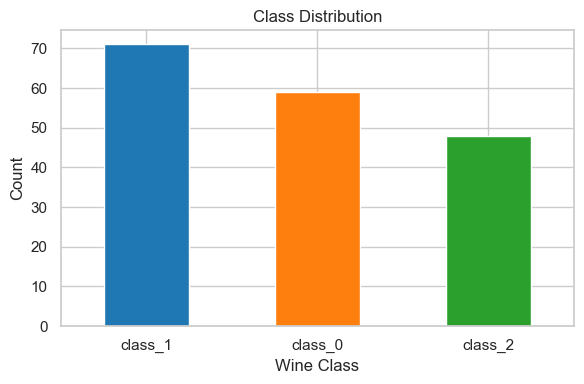

In [6]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
df["target_name"].value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e", "#2ca02c"], ax=ax)
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Wine Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

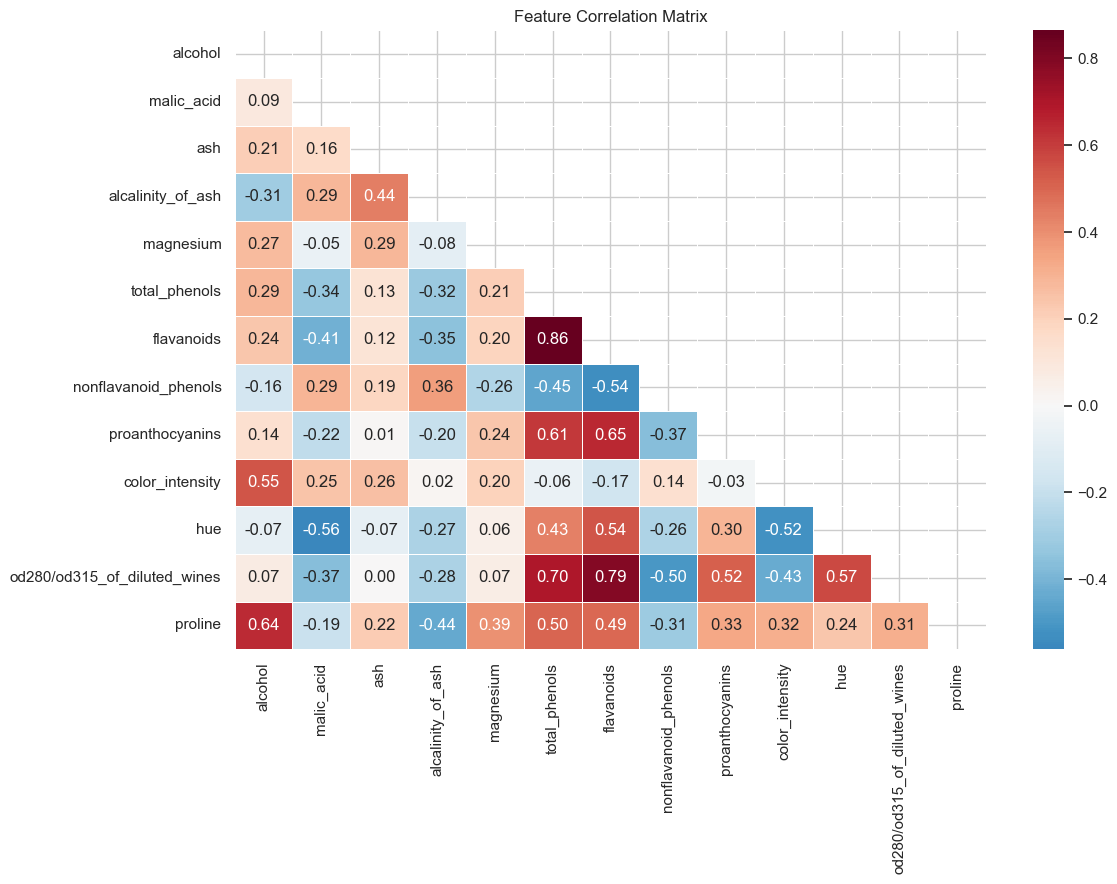

In [7]:
# Correlation heatmap (correllogram)
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[wine.feature_names].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

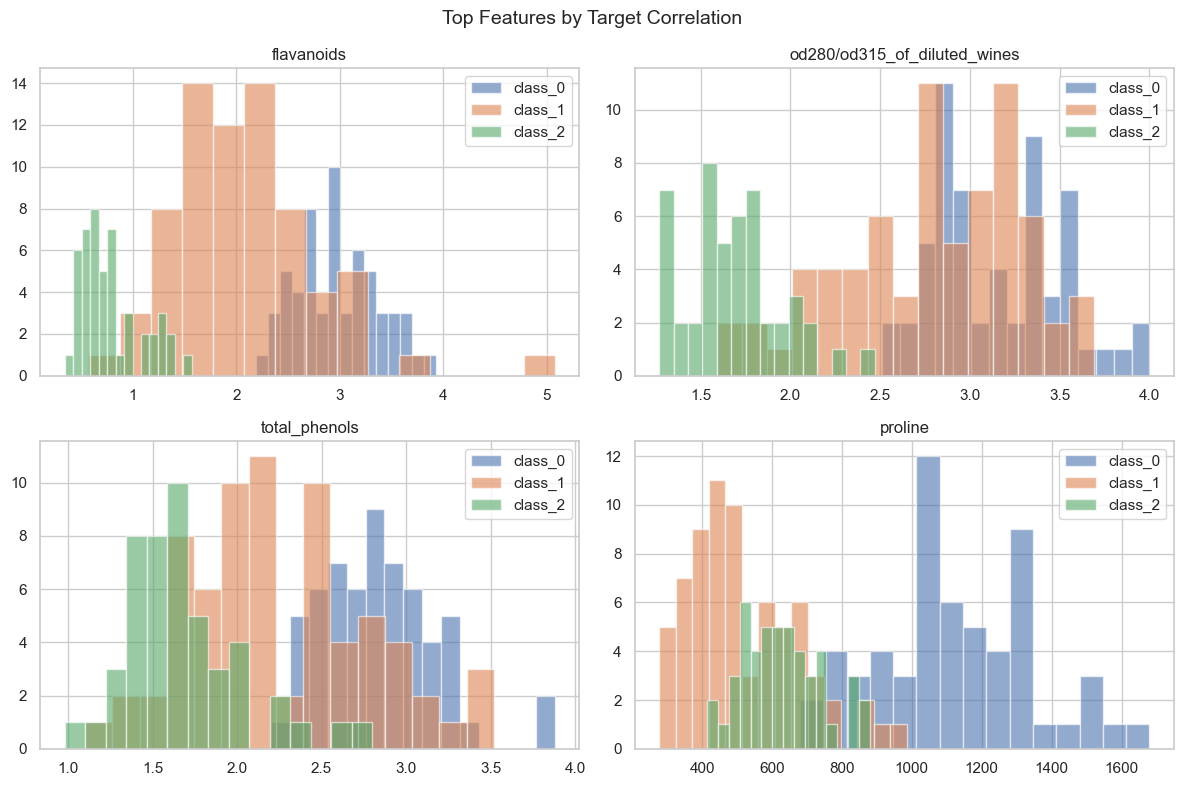

In [8]:
# Feature distributions by class (top 4 most correlated with target)
target_corr = df[wine.feature_names].corrwith(df["target"]).abs().sort_values(ascending=False)
top_features = target_corr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), top_features):
    for cls in sorted(df["target"].unique()):
        subset = df[df["target"] == cls]
        ax.hist(subset[feat], alpha=0.6, label=wine.target_names[cls], bins=15)
    ax.set_title(feat)
    ax.legend()
plt.suptitle("Top Features by Target Correlation", fontsize=14)
plt.tight_layout()
plt.show()

### 2. Preprocessing & Train/Test Split

In [9]:
# Separate features and target
X = df[wine.feature_names].copy()
y = df["target"].copy()

# Train (60%) / Validation (20%) / Test (20%) split with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"\nSplit ratios: 60/20/20 with stratification to preserve class balance")

Training set:   106 samples
Validation set: 36 samples
Test set:       36 samples

Split ratios: 60/20/20 with stratification to preserve class balance


In [10]:
# Scale features using StandardScaler (fit on train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=wine.feature_names, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=wine.feature_names, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=wine.feature_names, index=X_test.index)

print("Feature scaling complete (StandardScaler fit on training set).")
print(f"Train mean ≈ 0: {X_train_scaled.mean().mean():.6f}")
print(f"Train std  ≈ 1: {X_train_scaled.std().mean():.6f}")

Feature scaling complete (StandardScaler fit on training set).
Train mean ≈ 0: -0.000000
Train std  ≈ 1: 1.004751


### 3. Hyperparameter Tuning with Optuna + Cross-Validation

- Set up mlflow experiment in the databricks workspace

In [13]:
# Set up MLflow experiment
experiment_name = "/Users/q.yu@databricks.com/xgboost_wine_classification"

# To log the experiment using databricks UC model registry
mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")

mlflow.set_experiment(experiment_name)
print(f"MLflow experiment: {experiment_name}")

MLflow experiment: /Users/q.yu@databricks.com/xgboost_wine_classification


In [14]:
# Disable autologging during tuning to avoid conflicts with nested runs
mlflow.xgboost.autolog(disable=True)

# Combine train+val for cross-validation during tuning
X_tune = pd.concat([X_train_scaled, X_val_scaled])
y_tune = pd.concat([y_train, y_val])

def objective(trial):
    """Optuna objective: 5-fold stratified CV accuracy with XGBoost.
    Each trial is logged as a separate MLflow run for comparison."""
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "verbosity": 0,
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_tune, y_tune, cv=cv, scoring="accuracy")
    mean_acc = scores.mean()
    std_acc = scores.std()

    # Log each trial as a separate MLflow run
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_params({
            k: v for k, v in params.items()
            if k not in ("objective", "num_class", "eval_metric", "random_state", "verbosity")
        })
        mlflow.log_metrics({
            "cv_accuracy_mean": mean_acc,
            "cv_accuracy_std": std_acc,
        })
        mlflow.set_tag("optuna_trial", trial.number)

    return mean_acc

# Run Optuna study inside a parent MLflow run
with mlflow.start_run(run_name="optuna_tuning") as parent_run:
    study = optuna.create_study(direction="maximize", study_name="xgboost_wine")
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    mlflow.log_metrics({"best_cv_accuracy": study.best_value})
    mlflow.log_params({"n_trials": 50})
    parent_run_id = parent_run.info.run_id

print(f"\nParent run ID: {parent_run_id}")
print(f"Best CV accuracy: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")
print(f"\n\u2705 {len(study.trials)} trials logged as nested MLflow runs \u2014 compare them in the Experiment UI")

  0%|          | 0/50 [00:00<?, ?it/s]

🏃 View run trial_0 at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848/runs/ac6d91ac92fd4edc8dd22099f483432f
🧪 View experiment at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848


Best trial: 0. Best value: 0.950493:   2%|▏         | 1/50 [00:05<04:10,  5.11s/it]

🏃 View run trial_1 at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848/runs/d69752d692274594b7c419dae9ee7ce5
🧪 View experiment at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848


Best trial: 0. Best value: 0.950493:   4%|▍         | 2/50 [00:09<03:48,  4.76s/it]

...

🏃 View run trial_48 at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848/runs/40f545e9bbe74439bd1a6c16bf312ae8
🧪 View experiment at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848


Best trial: 19. Best value: 0.979064:  98%|█████████▊| 49/50 [04:27<00:05,  5.13s/it]

🏃 View run trial_49 at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848/runs/58a92cdc49e14ba5b0dba2b82d5dc549
🧪 View experiment at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848


Best trial: 19. Best value: 0.979064: 100%|██████████| 50/50 [04:32<00:00,  5.45s/it]


🏃 View run optuna_tuning at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848/runs/3e6c16b10b1d40528504daf23562aa66
🧪 View experiment at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848

Parent run ID: 3e6c16b10b1d40528504daf23562aa66
Best CV accuracy: 0.9791
Best params: {'n_estimators': 60, 'max_depth': 10, 'learning_rate': 0.011283294667895448, 'subsample': 0.8487508204822909, 'colsample_bytree': 0.6048959507061942, 'min_child_weight': 2, 'gamma': 1.7357348722857888, 'reg_alpha': 2.2509554821266337e-07, 'reg_lambda': 1.0606755705839124}

✅ 50 trials logged as nested MLflow runs — compare them in the Experiment UI


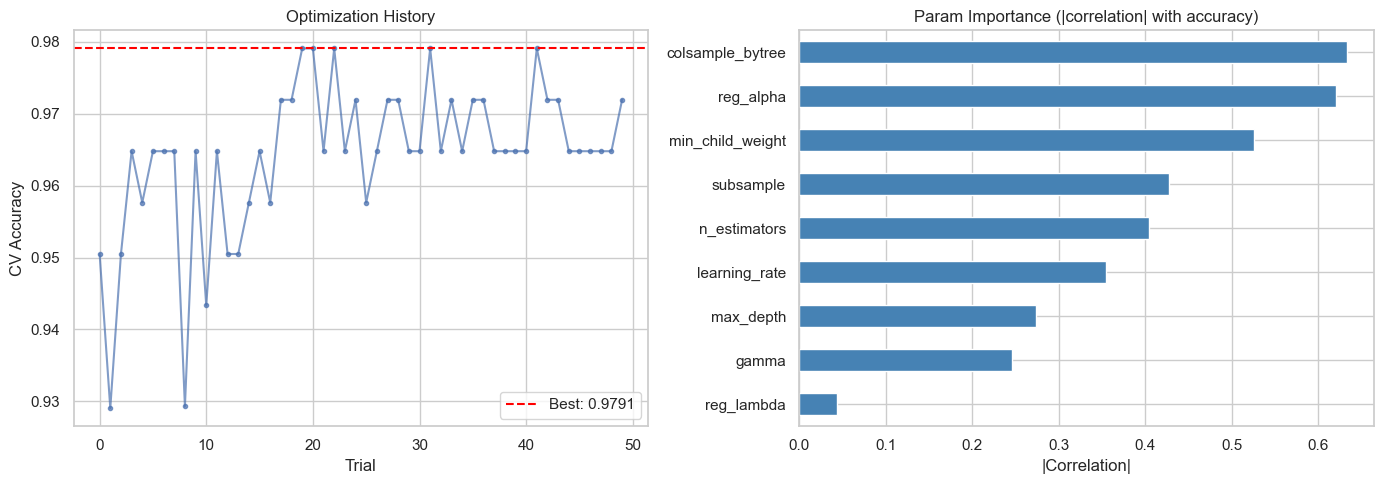

In [15]:
# Visualize tuning results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df["number"], trials_df["value"], "o-", markersize=3, alpha=0.7)
axes[0].axhline(study.best_value, color="red", linestyle="--", label=f"Best: {study.best_value:.4f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV Accuracy")
axes[0].set_title("Optimization History")
axes[0].legend()

# Parameter importance (top params by correlation with accuracy)
param_cols = [c for c in trials_df.columns if c.startswith("params_")]
importances = trials_df[param_cols].corrwith(trials_df["value"]).abs().sort_values(ascending=True)
importances.index = [c.replace("params_", "") for c in importances.index]
importances.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Param Importance (|correlation| with accuracy)")
axes[1].set_xlabel("|Correlation|")

plt.tight_layout()
plt.show()

### 4. Train Final Model & Log to MLflow

In [16]:
# Train the best model on train+val, evaluate on held-out test set
best_params = study.best_params
best_params.update({
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "random_state": 42,
    "verbosity": 0,
})

# End any active run from the tuning cell
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="xgboost_best_model") as run:
    # Enable autologging for XGBoost
    mlflow.xgboost.autolog(log_models=False)  # we'll log manually with signature

    # Train
    best_model = xgb.XGBClassifier(**best_params)
    best_model.fit(
        X_tune, y_tune,
        eval_set=[(X_test_scaled, y_test)],
        verbose=False
    )

    # Predictions
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)

    # Metrics
    metrics = {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        "test_f1_micro": f1_score(y_test, y_pred, average="micro"),
        "test_precision_macro": precision_score(y_test, y_pred, average="macro"),
        "test_recall_macro": recall_score(y_test, y_pred, average="macro"),
        "test_roc_auc_ovr": roc_auc_score(y_test, y_proba, multi_class="ovr"),
    }
    mlflow.log_metrics(metrics)
    mlflow.log_params({"best_cv_accuracy": study.best_value, "n_optuna_trials": 50})

    # Log model with signature
    signature = infer_signature(X_test_scaled, y_pred)
    mlflow.xgboost.log_model(
        best_model,
        artifact_path="xgboost_model",
        signature=signature,
        input_example=X_test_scaled.iloc[:3],
    )

    run_id = run.info.run_id
    print(f"MLflow Run ID: {run_id}")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

2026/05/12 00:07:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848/models/m-887d36d7176b48f69e31c8ac2a41eb94
2026/05/12 00:07:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/12 00:07:25 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


MLflow Run ID: 714deec92ca840f3bd891a8a583abd07
  test_accuracy: 1.0000
  test_f1_macro: 1.0000
  test_f1_micro: 1.0000
  test_precision_macro: 1.0000
  test_recall_macro: 1.0000
  test_roc_auc_ovr: 1.0000
🏃 View run xgboost_best_model at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848/runs/714deec92ca840f3bd891a8a583abd07
🧪 View experiment at: https://e2-demo-field-eng.cloud.databricks.com/ml/experiments/2019445883642848


### 5. Evaluation

In [17]:
# Classification report
print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        15
     class_2       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



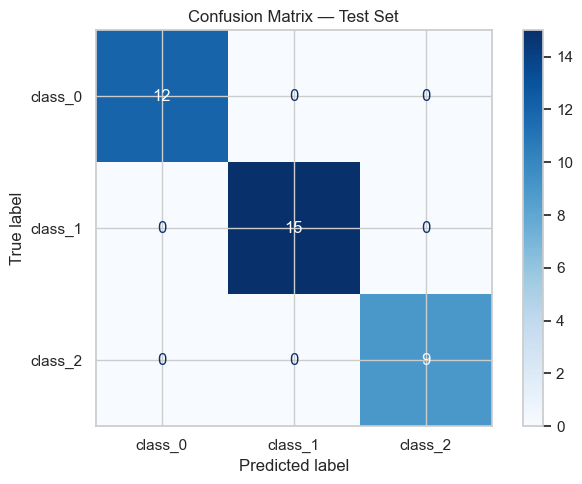

In [18]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=wine.target_names)
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

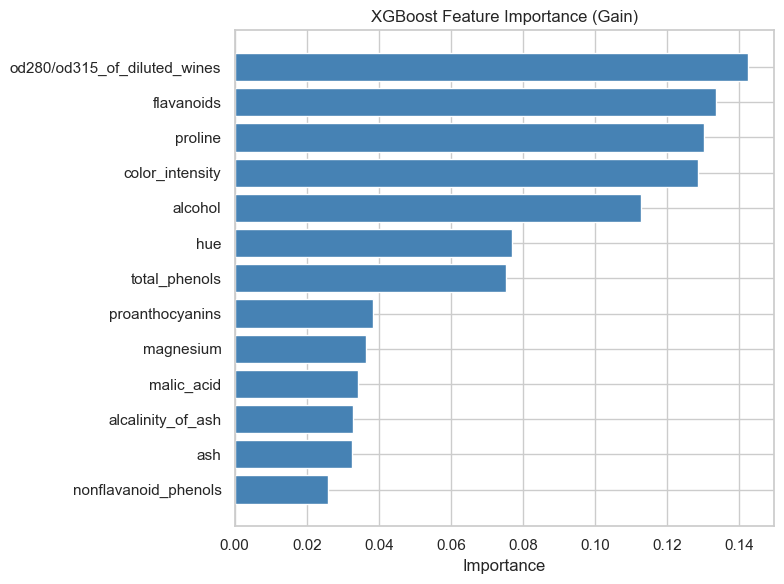

In [19]:
# Feature importance (gain-based)
importance_df = pd.DataFrame({
    "Feature": wine.feature_names,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
ax.set_title("XGBoost Feature Importance (Gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

### 6. Register Model to Unity Catalog

> **Note:** Update the catalog and schema below to match your workspace (e.g. `users.your_schema`).

In [20]:
# Register the best model to Unity Catalog
mlflow.set_registry_uri("databricks-uc")

CATALOG = "fins_genai"
SCHEMA = "classic_ml"  # Update to your schema
MODEL_NAME = f"{CATALOG}.{SCHEMA}.xgboost_wine_classifier"

model_uri = f"runs:/{run_id}/xgboost_model"
registered_model = mlflow.register_model(model_uri, MODEL_NAME)

print(f"Model registered: {MODEL_NAME}")
print(f"Version: {registered_model.version}")

Successfully registered model 'fins_genai.classic_ml.xgboost_wine_classifier'.
2026/05/12 00:14:43 WARNING mlflow.tracking._model_registry.fluent: Run with id 714deec92ca840f3bd891a8a583abd07 has no artifacts at artifact path 'xgboost_model', registering model based on models:/m-887d36d7176b48f69e31c8ac2a41eb94 instead
Uploading artifacts: 100%|██████████| 9/9 [00:01<00:00,  7.15it/s]
🔗 Created version '1' of model 'fins_genai.classic_ml.xgboost_wine_classifier': https://e2-demo-field-eng.cloud.databricks.com/explore/data/models/fins_genai/classic_ml/xgboost_wine_classifier/version/1


Model registered: fins_genai.classic_ml.xgboost_wine_classifier
Version: 1
